In [520]:
ar <- arima.sim(model = list(order = c(3, 0, 0), ar = c(0.1,0.5,-0.3)), n = 120)
ma <- arima.sim(model = list(order = c(0, 0, 5), ma = c(0.5,-0.1,0.4,0.3,-0.2)), n = 120)
arma <- arima.sim(model = list(order = c(2, 0, 2), ar = c(0.6,0.1), ma=c(-0.5,0.4)), n = 120)
arima <- arima.sim(model = list(order = c(2, 1, 2), ar = c(0.6,0.1), ma=c(-0.5,0.4)), n = 120,sd=0.1)


In [521]:
m_ar <- arima(ar[0:80],order = c(3,0,0))
pred_ar <- predict(m_ar,n.ahead = 40)
CI_ar <- qnorm(0.975)*pred_ar$se

In [522]:
m_ma <- arima(ma[0:80],order = c(0,0,5))
pred_ma <- predict(m_ma,n.ahead = 40)
CI_ma <- qnorm(0.975)*pred_ma$se

In [523]:
m_arma <- arima(arma[0:80],order = c(2,0,2))
pred_arma <- predict(m_arma,n.ahead = 40)
CI_arma <- qnorm(0.975)*pred_arma$se

In [524]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)

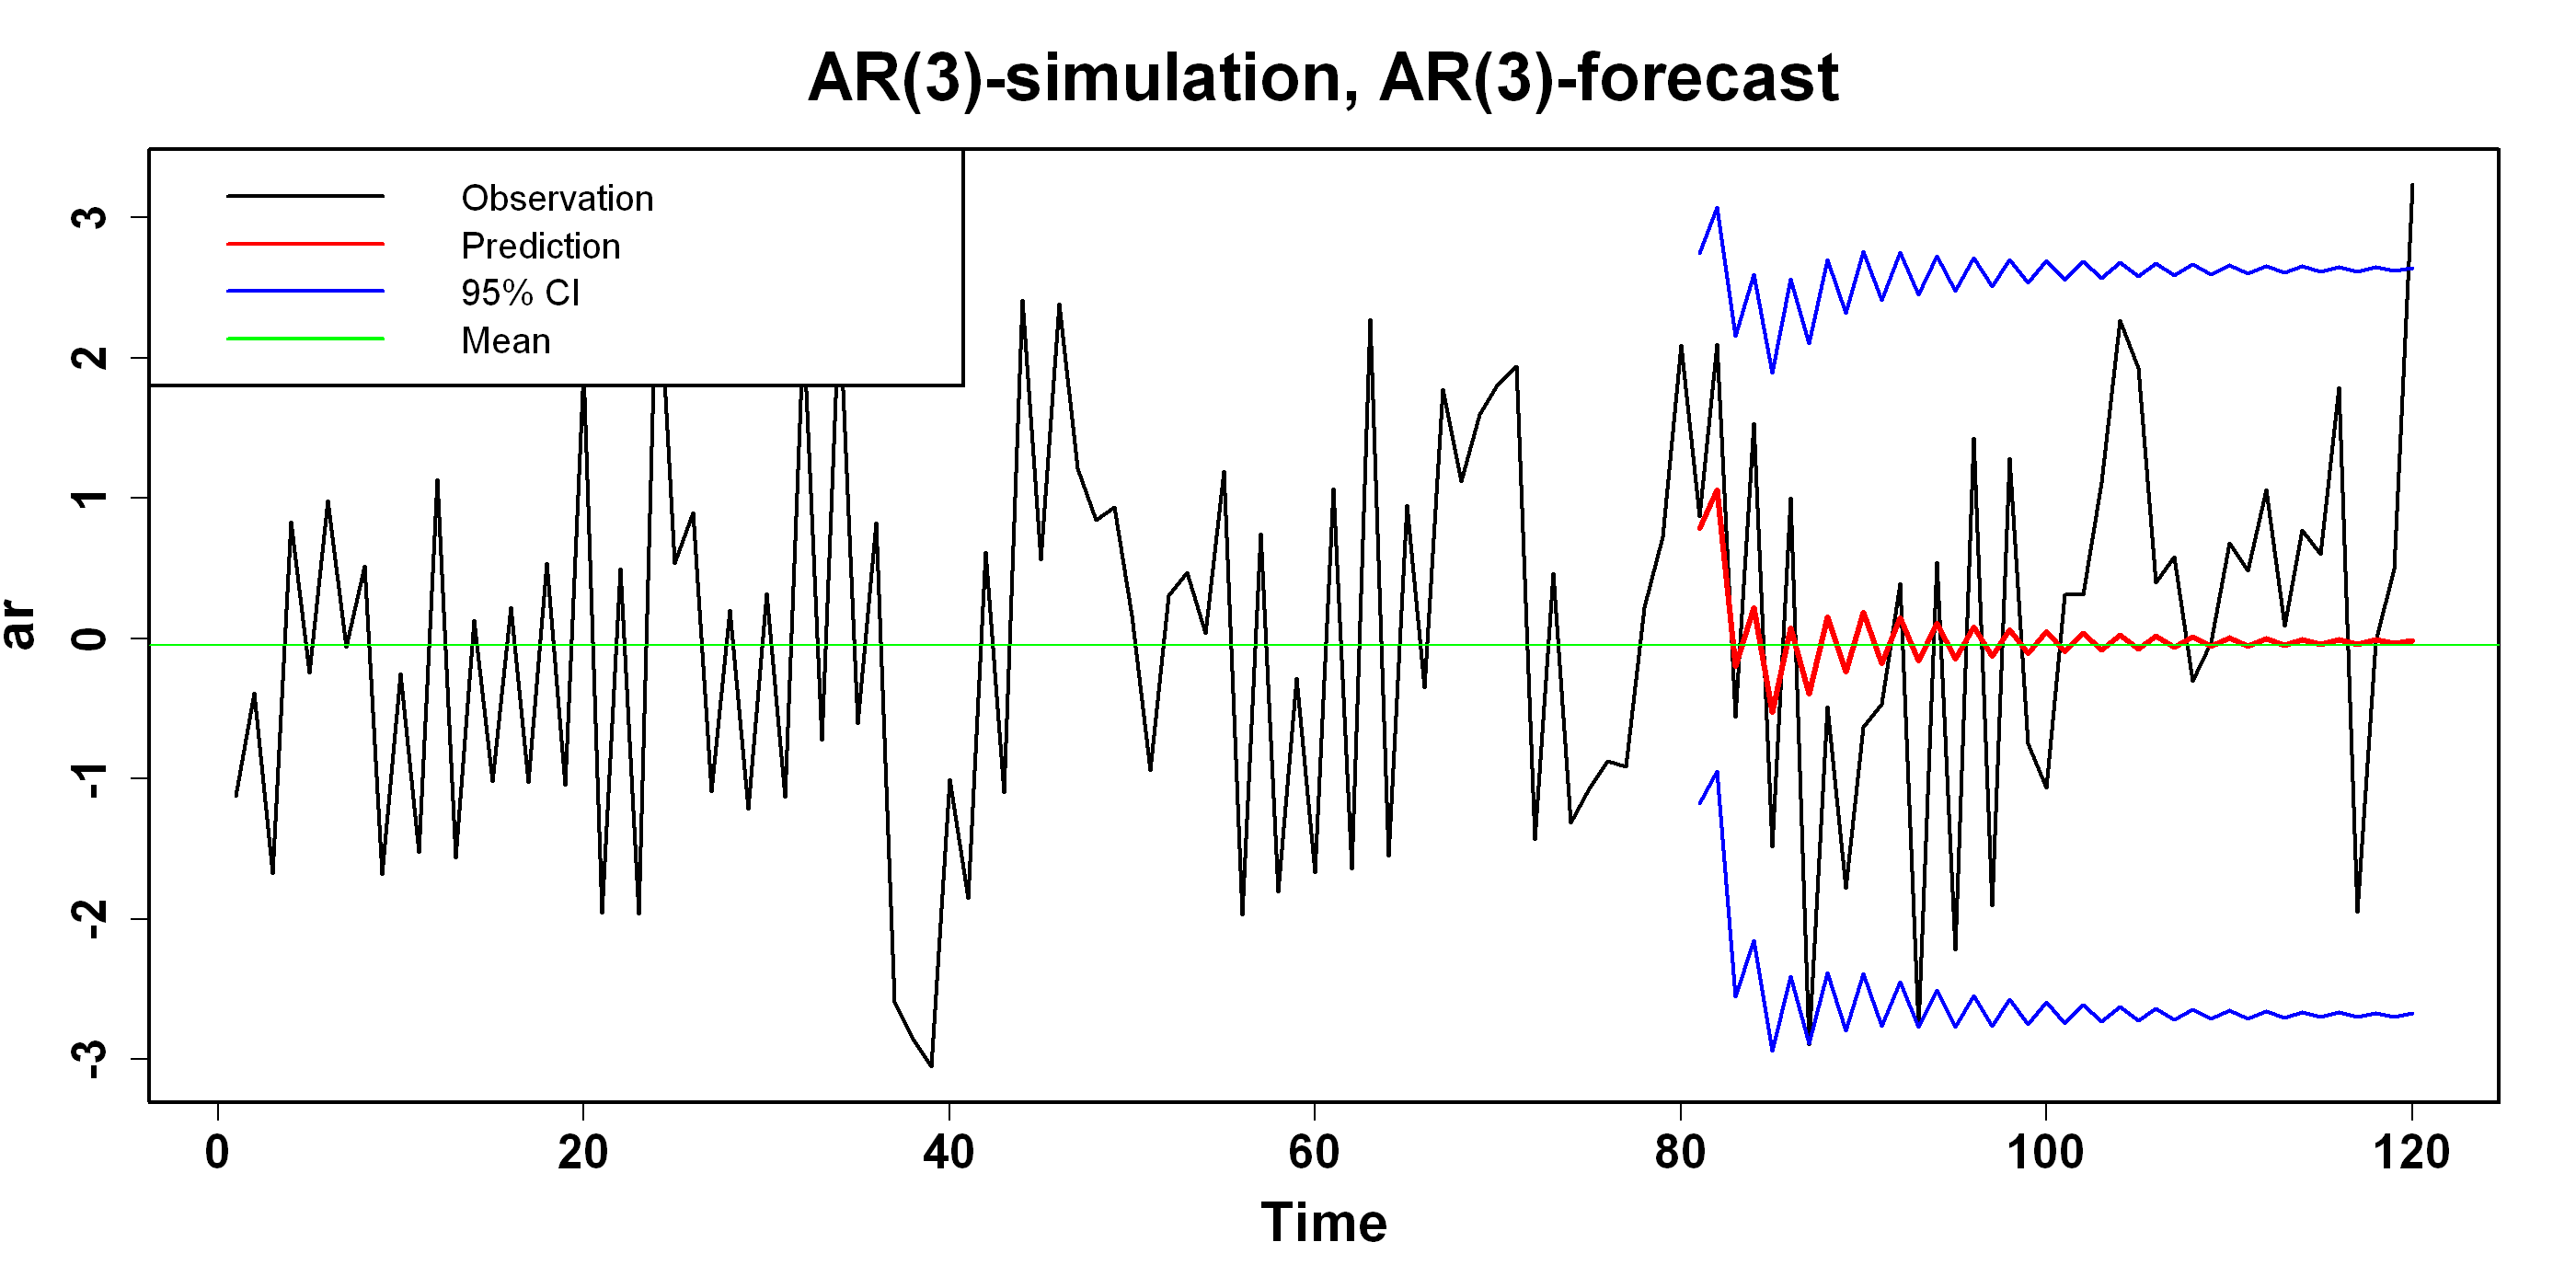

In [525]:
par(font.axis = 2, font.lab = 2, font.main = 2,
    cex.axis = 1.6, cex.lab = 1.8, cex.main = 2.2, lwd = 2)
plot(ar,lwd=2,main="AR(3)-simulation, AR(3)-forecast")
lines(pred_ar$pred,col="red",lwd=3)
lines(pred_ar$pred-CI_ar,col="blue",lwd = 2)
lines(pred_ar$pred+CI_ar,col="blue",lwd=2)
abline(h=mean(ar[0:80]),col="green",lwd=1)


legend("topleft", legend = c("Observation","Prediction","95% CI","Mean"), lty=c(1,1,1,1), col=c("black","red","blue","green"),text.font = 1.2, cex = 1.2)

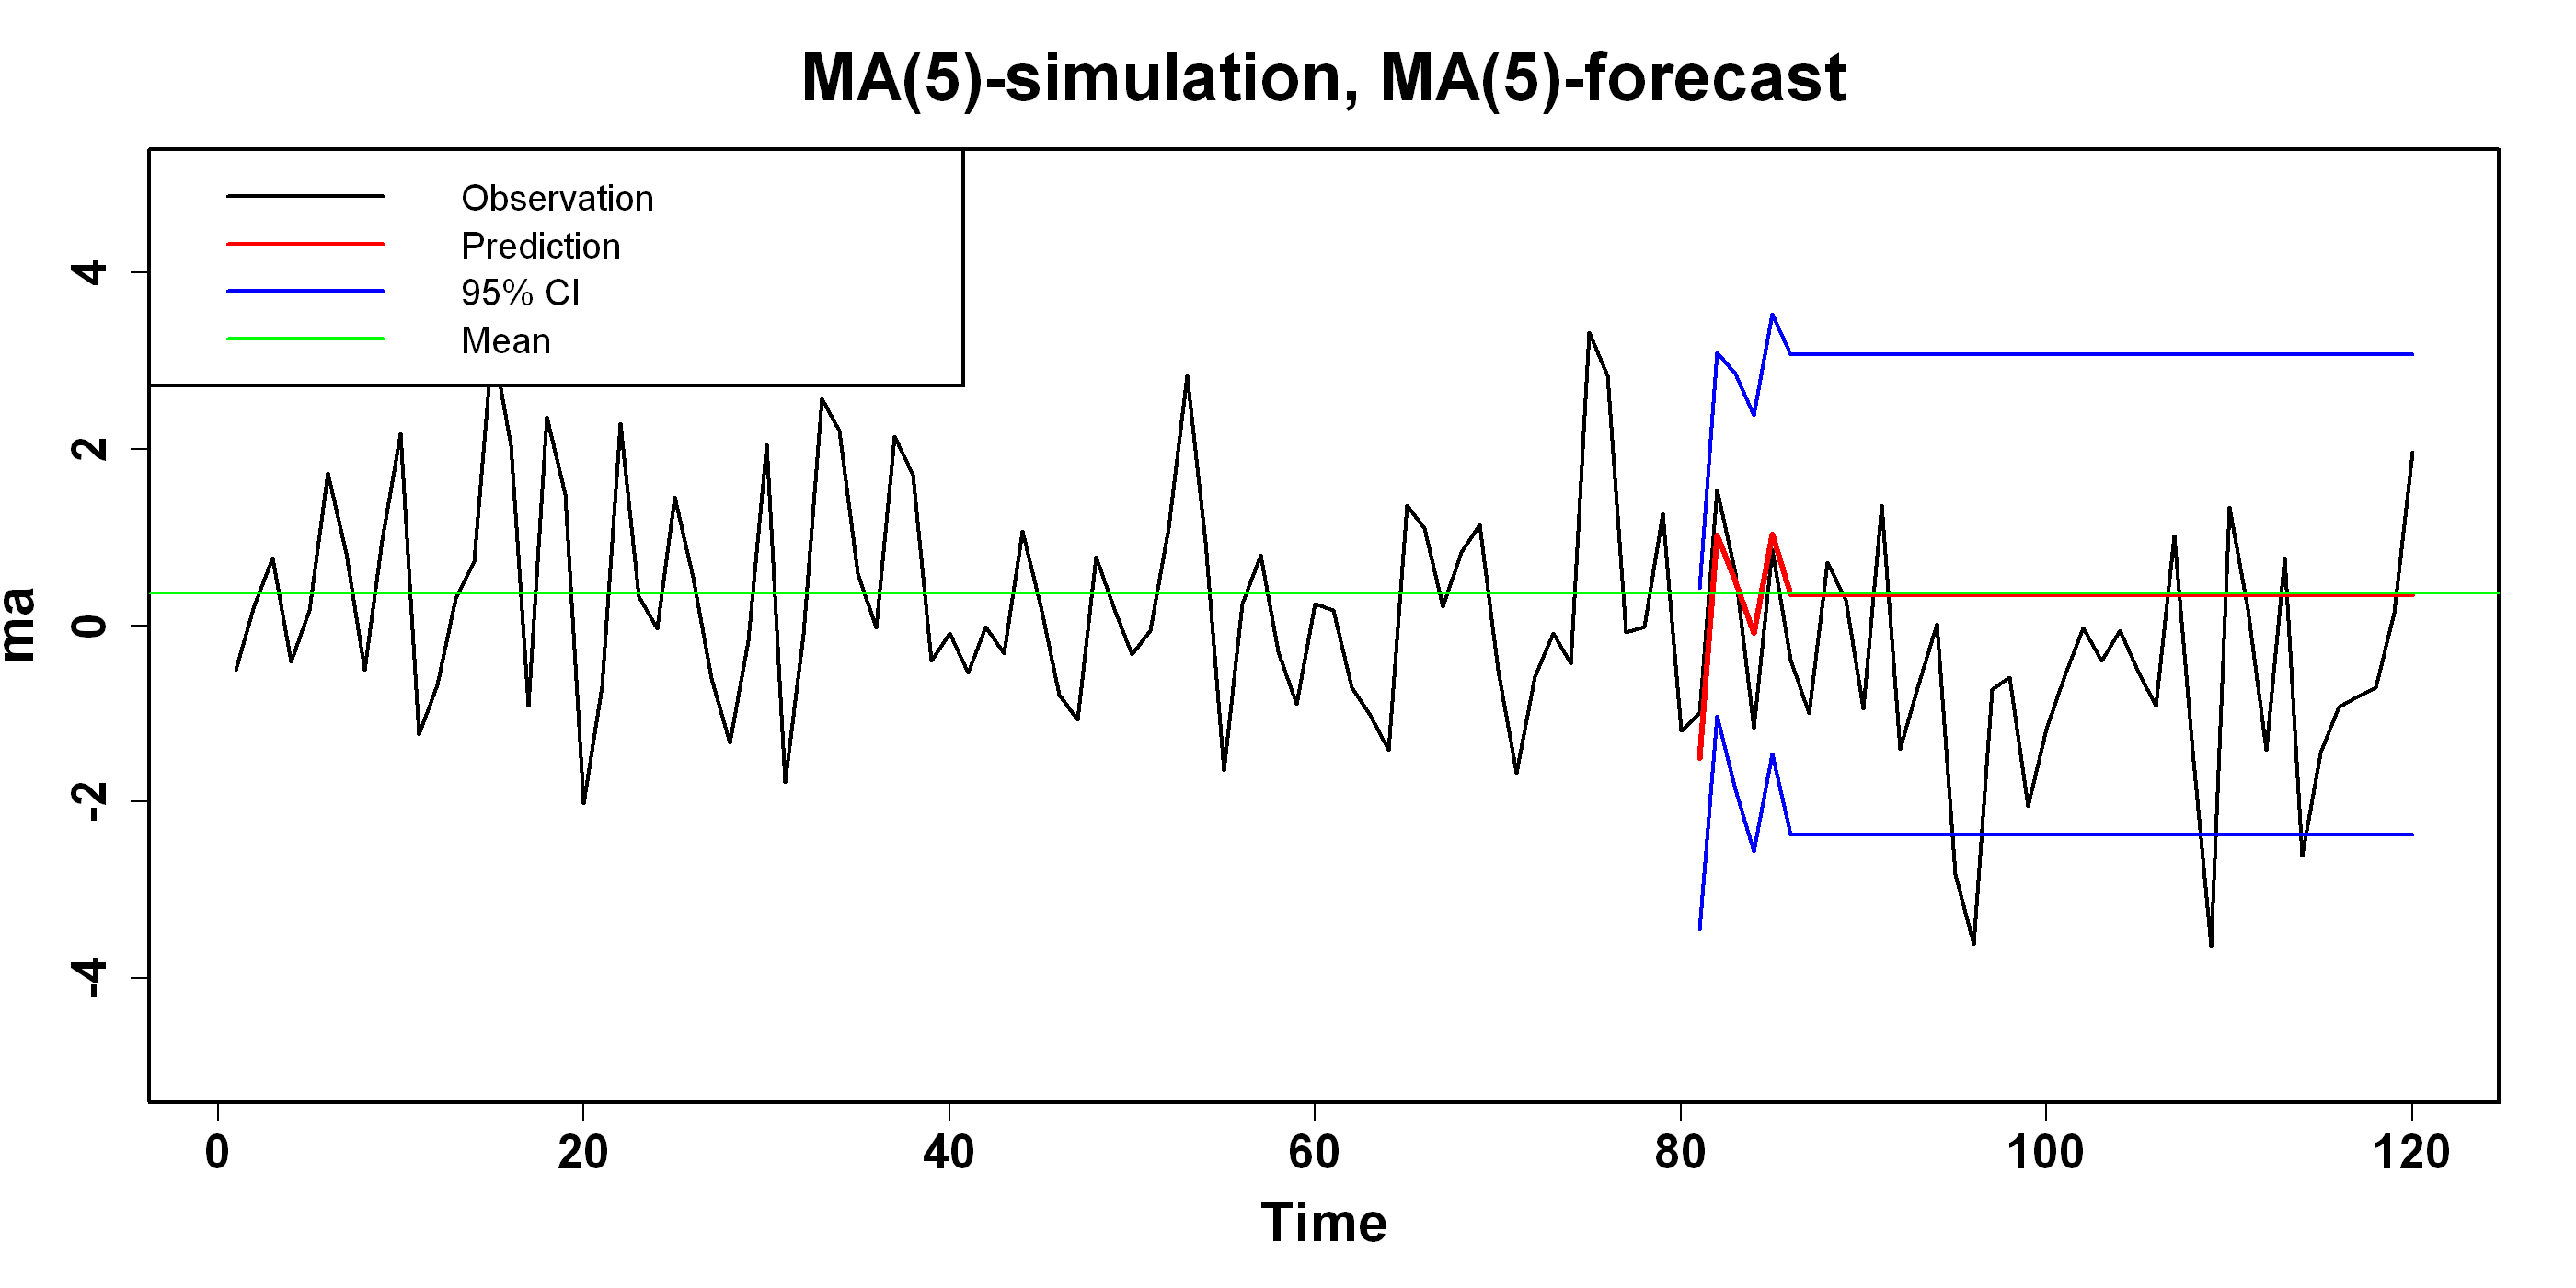

In [526]:
par(font.axis = 2, font.lab = 2, font.main = 2,
    cex.axis = 1.6, cex.lab = 1.8, cex.main = 2.2, lwd = 2)
plot(ma,ylim=c(-5,5),lwd=2,main="MA(5)-simulation, MA(5)-forecast")
lines(pred_ma$pred,col="red",lwd=3)
lines(pred_ma$pred-CI_ma,col="blue",lwd = 2)
lines(pred_ma$pred+CI_ma,col="blue",lwd=2)
abline(h=mean(ma[0:80]),col="green",lwd=1)
legend("topleft", legend = c("Observation","Prediction","95% CI","Mean"), lty=c(1,1,1,1), col=c("black","red","blue","green"),text.font = 1.2, cex = 1.2)

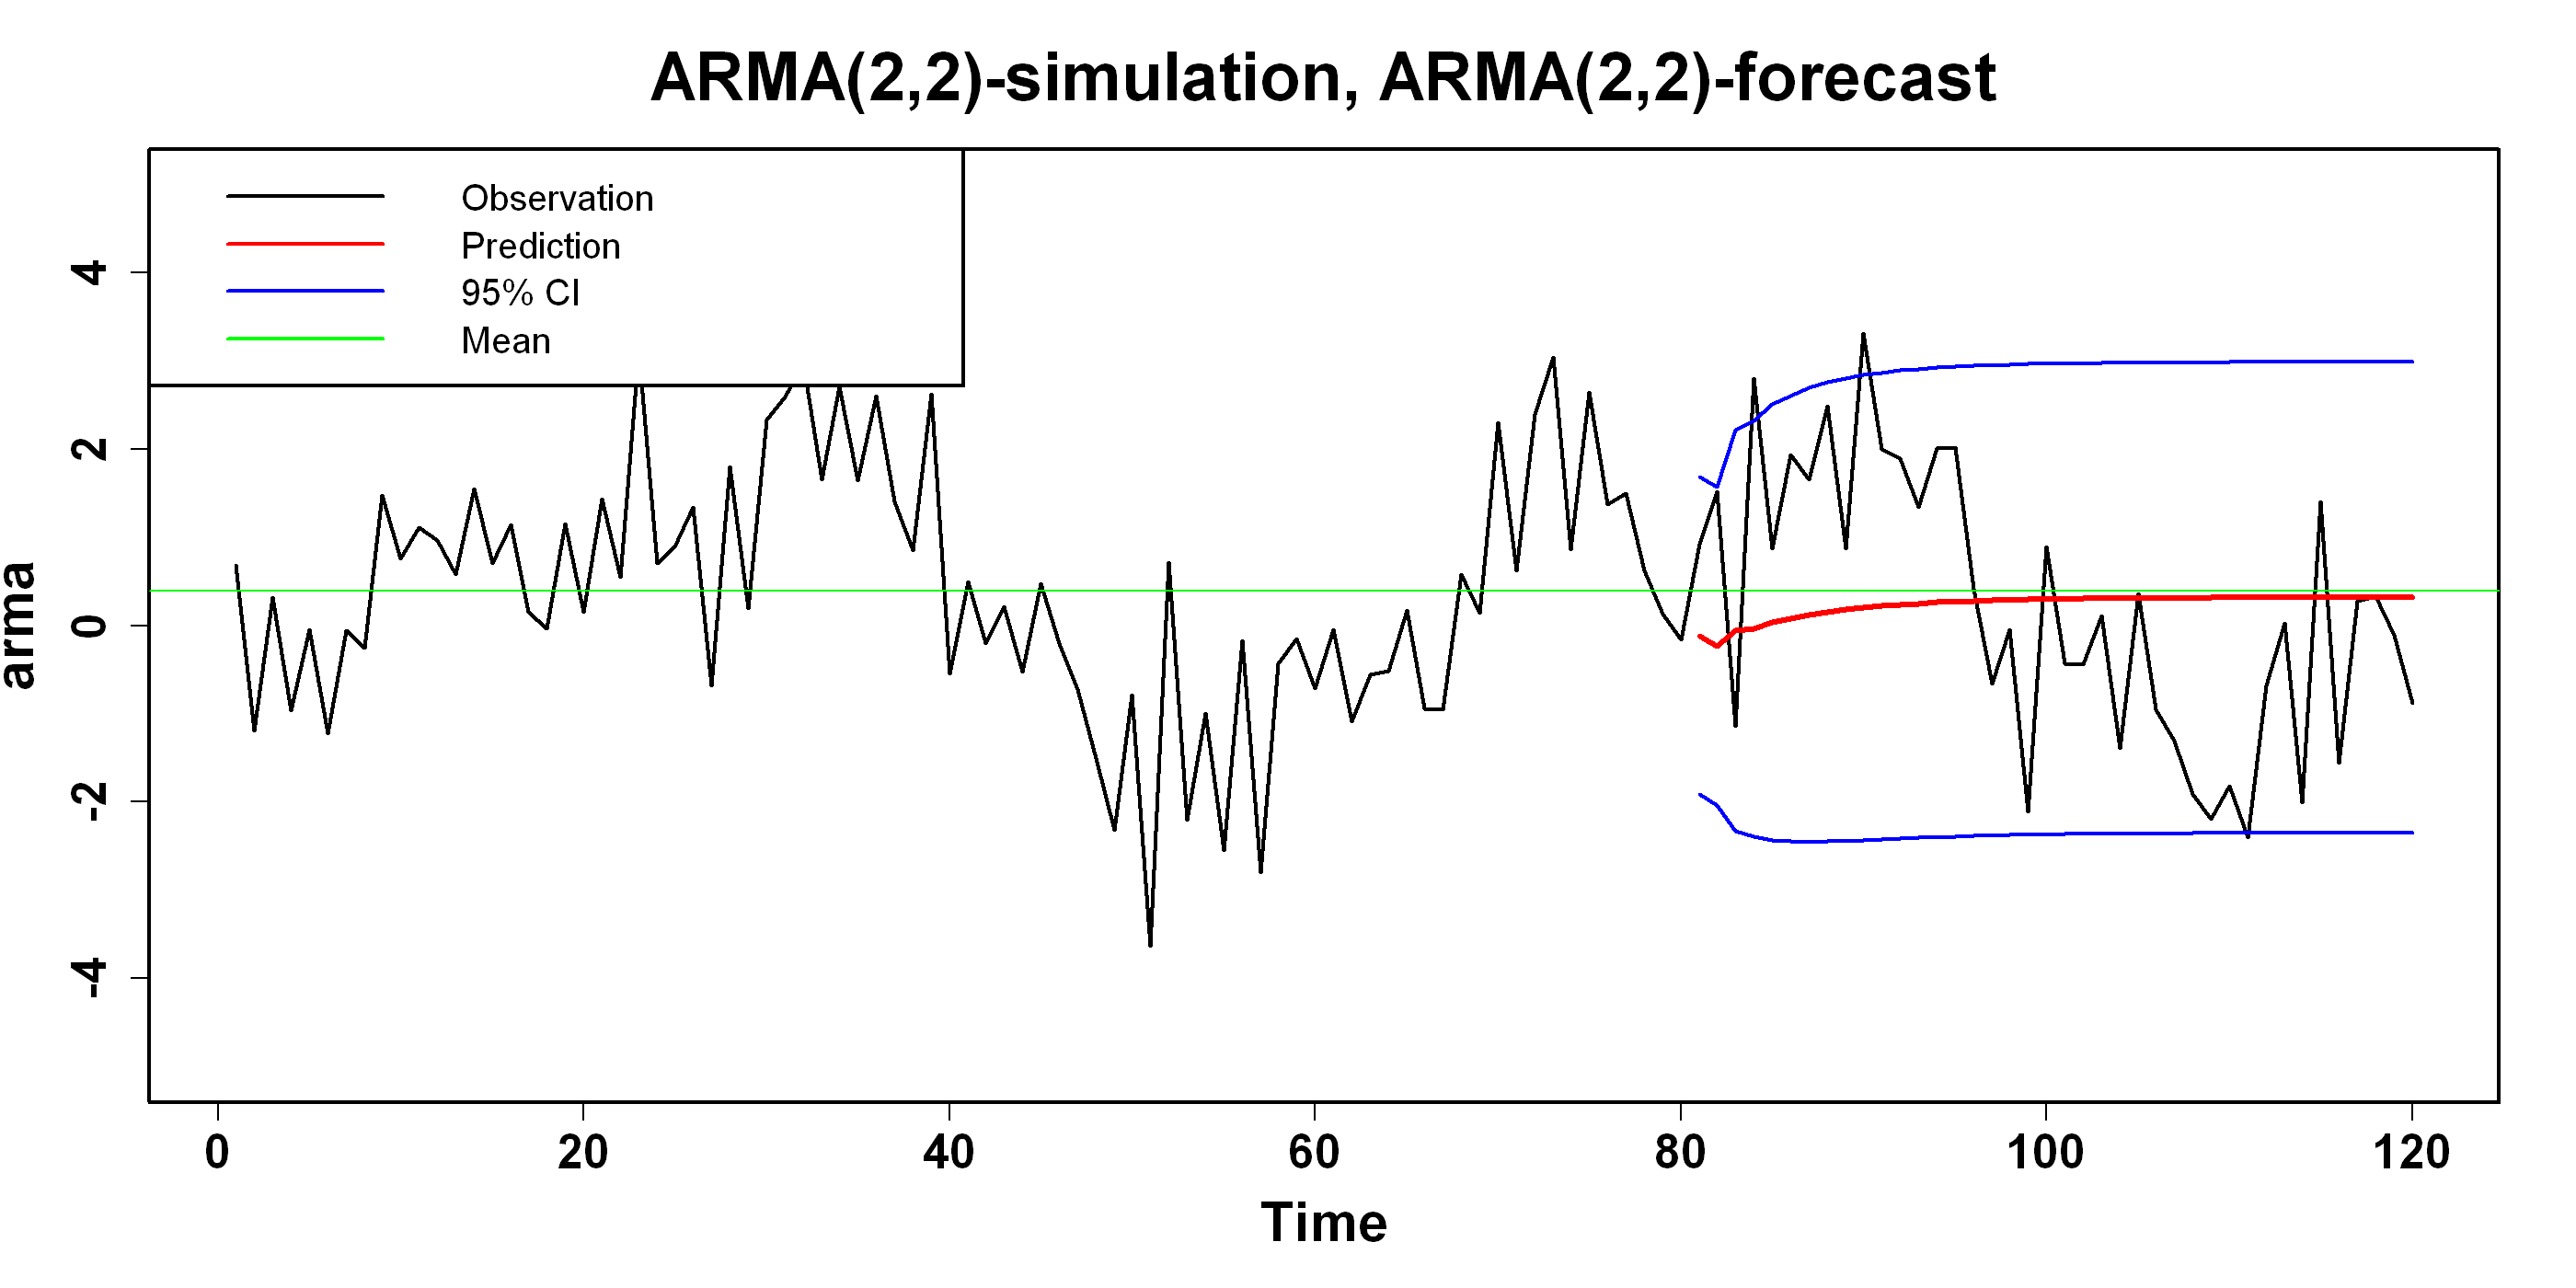

In [527]:
par(font.axis = 2, font.lab = 2, font.main = 2,
    cex.axis = 1.6, cex.lab = 1.8, cex.main = 2.2, lwd = 2)
plot(arma,ylim=c(-5,5),lwd=2,main="ARMA(2,2)-simulation, ARMA(2,2)-forecast")
lines(pred_arma$pred,col="red",lwd=3)
lines(pred_arma$pred-CI_arma,col="blue",lwd = 2)
lines(pred_arma$pred+CI_arma,col="blue",lwd=2)
abline(h=mean(arma[0:80]),col="green",lwd=1)
legend("topleft", legend = c("Observation","Prediction","95% CI","Mean"), lty=c(1,1,1,1), col=c("black","red","blue","green"),text.font = 1.2, cex = 1.2)

In [528]:
m_arima <- arima(arima[0:80],order = c(2,1,2))
pred_arima <- predict(m_arima,n.ahead = 40)
CI_arima <- qnorm(0.975)*pred_arima$se

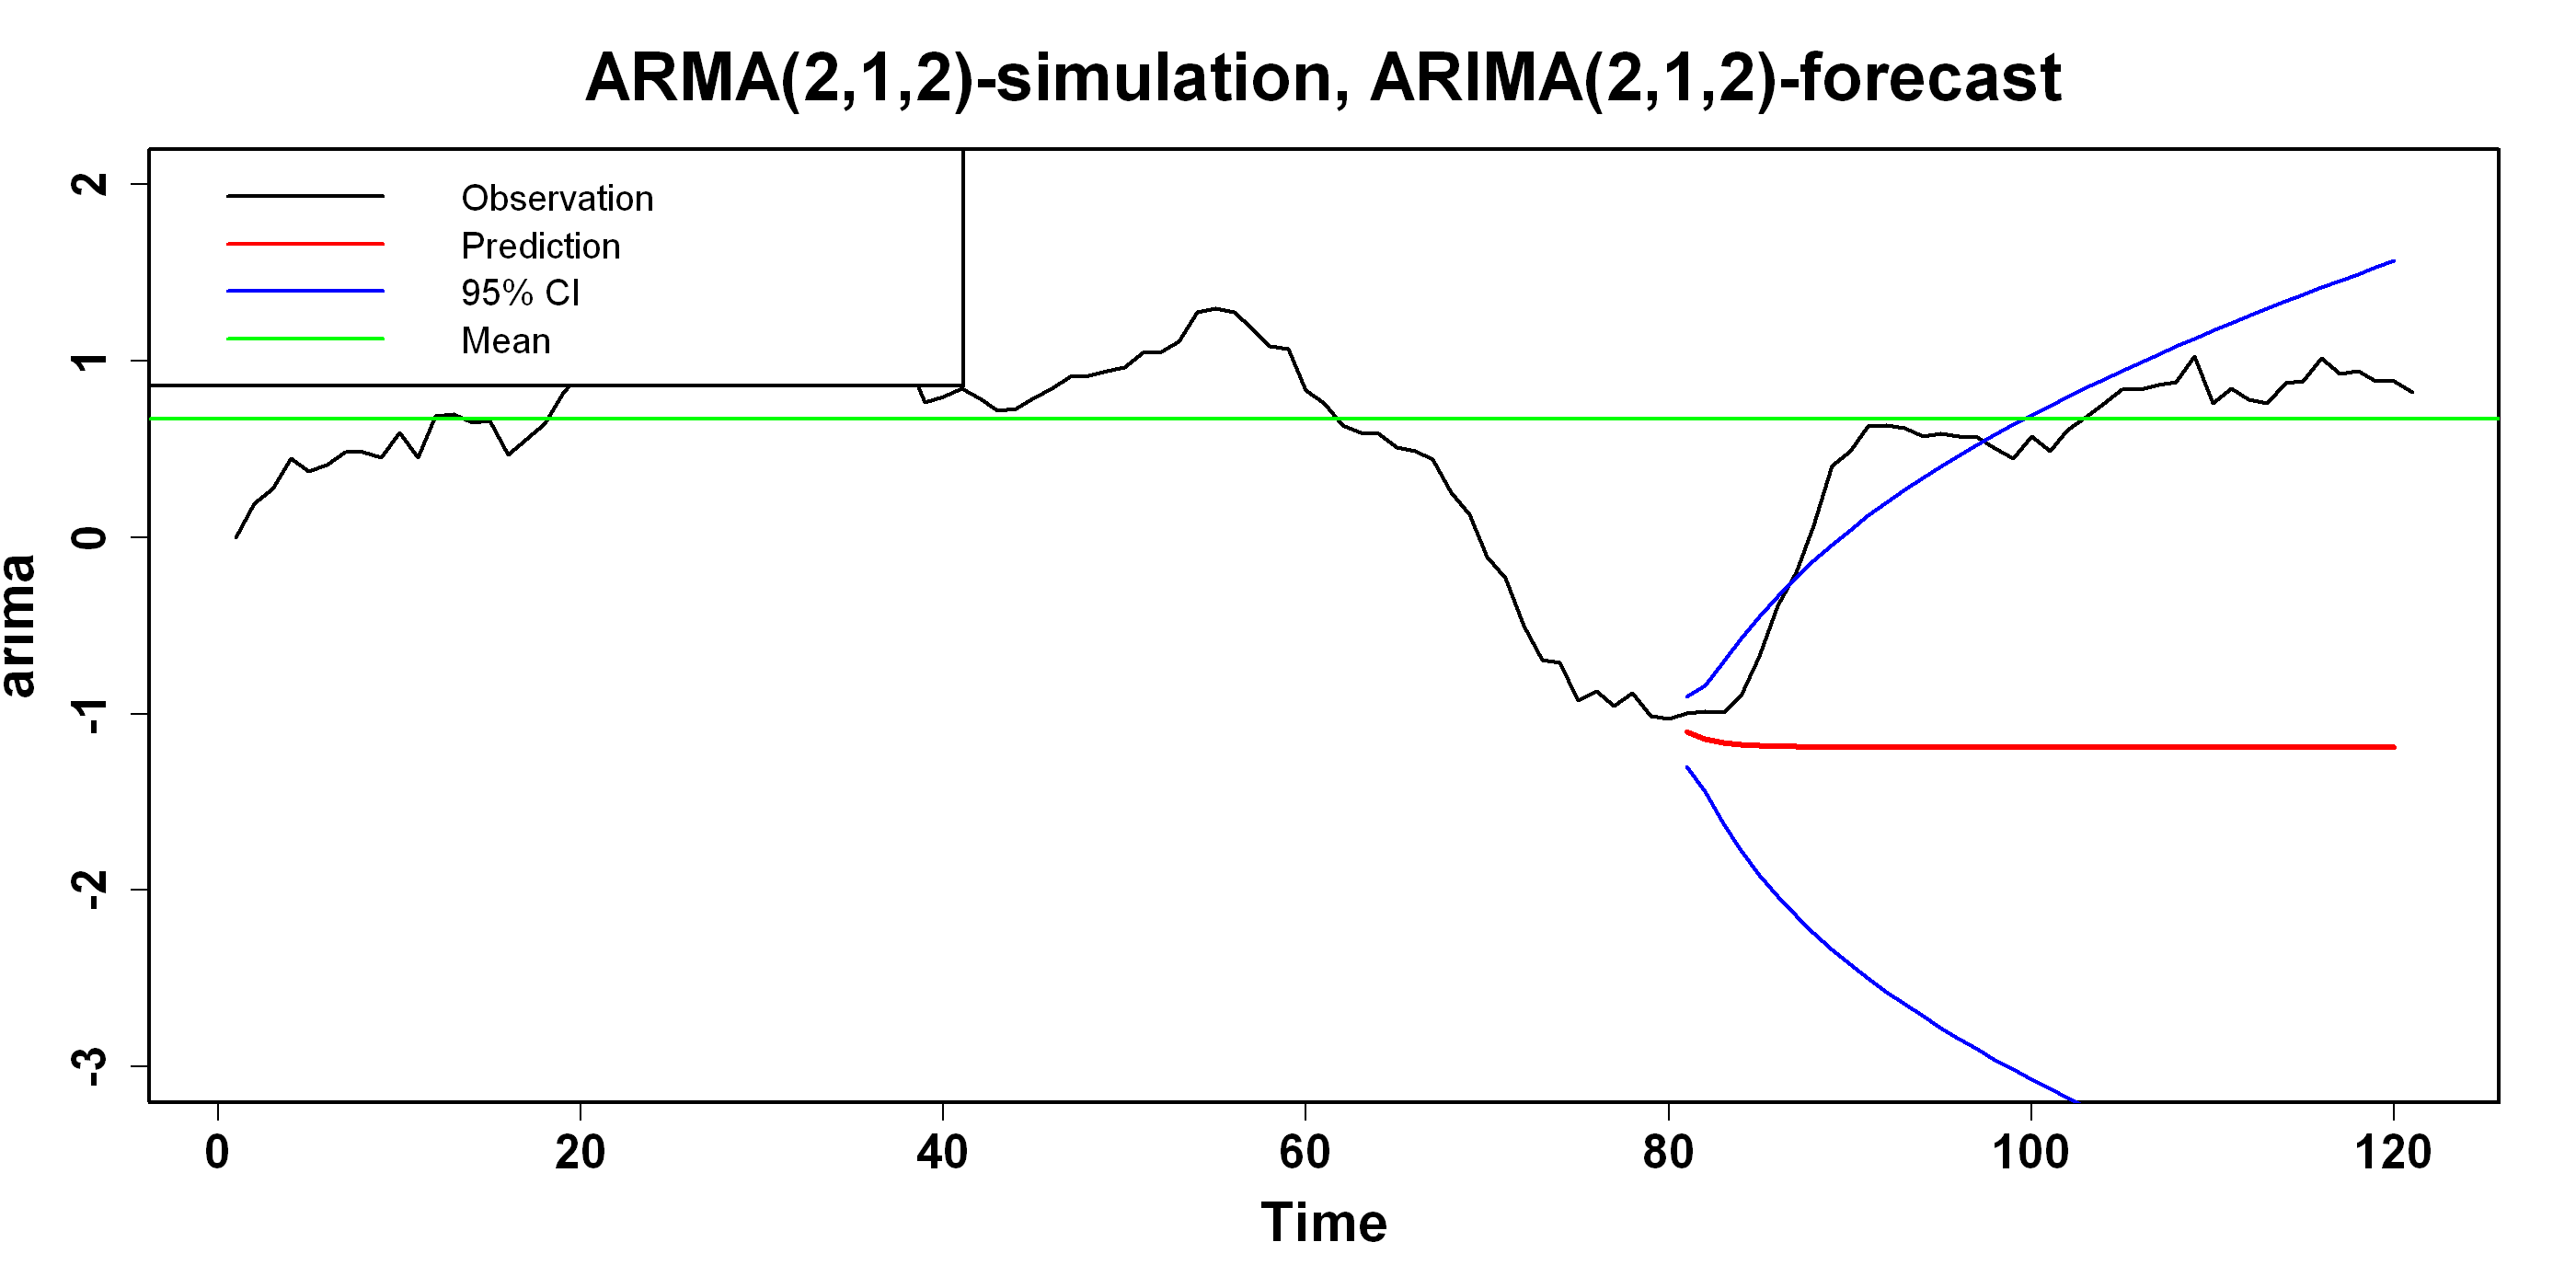

In [529]:
par(font.axis = 2, font.lab = 2, font.main = 2,
    cex.axis = 1.6, cex.lab = 1.8, cex.main = 2.2, lwd = 2)
plot(arima,lwd=2,main="ARMA(2,1,2)-simulation, ARIMA(2,1,2)-forecast",ylim=c(-3,2))
lines(pred_arima$pred,col="red",lwd=3)
lines(pred_arima$pred-CI_arima,col="blue",lwd = 2)
lines(pred_arima$pred+CI_arima,col="blue",lwd=2)
abline(h=mean(arima[0:80]),col="green")
legend("topleft", legend = c("Observation","Prediction","95% CI","Mean"), lty=c(1,1,1,1), col=c("black","red","blue","green"),text.font = 1.2, cex = 1.2)

In [530]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 200)

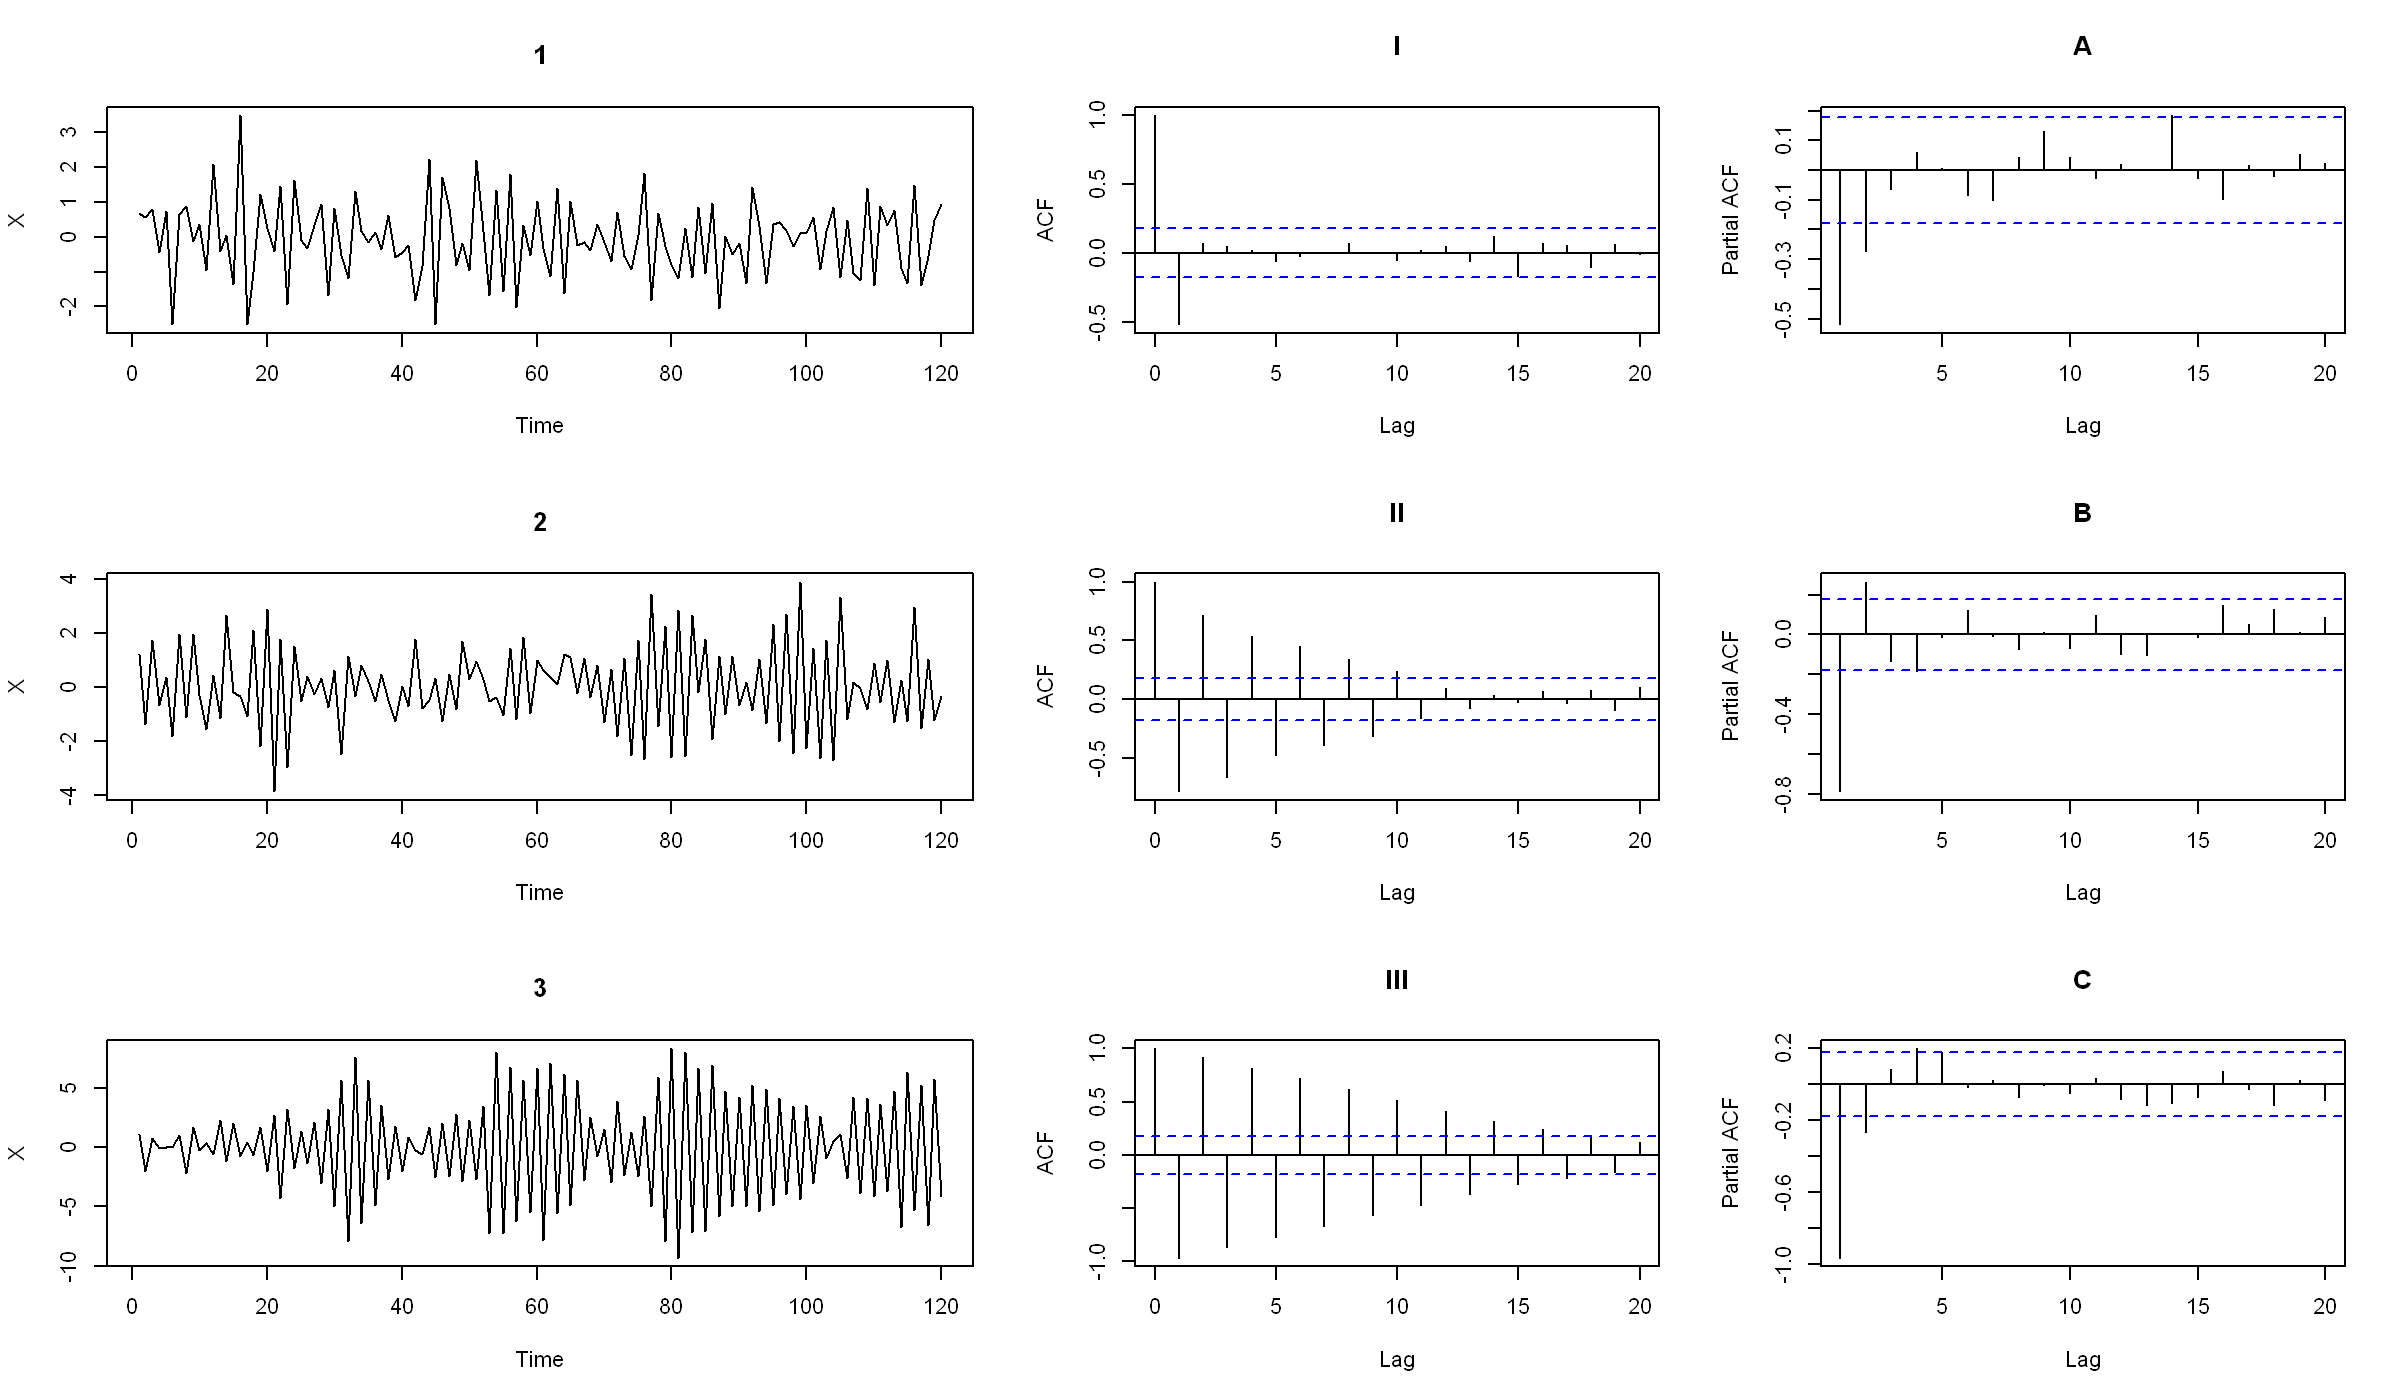

In [531]:
t <- arima.sim(model = list(order = c(0, 0, 2), ma = c(-0.6,0.3)), n = 120)
t2 <- arima.sim(model = list(order = c(2, 0, 0), ar = c(-0.6,0.3)), n = 120)
t3 <- arima.sim(model = list(order = c(2, 0, 2), ar = c(-0.6,0.3),ma = c(-0.6,0.3)), n = 120)

layout(matrix(1:9, 3, 3, byrow = TRUE), widths = c(1.5, 1, 1))
plot(t,main="1",ylab = "X")

acf(t,main="I")
pacf(t,main="A")

plot(t2,main="2",ylab = "X")
acf(t2,main="II")
pacf(t2,main="B")

plot(t3,main="3",ylab = "X")
acf(t3,main="III")
pacf(t3,main="C")

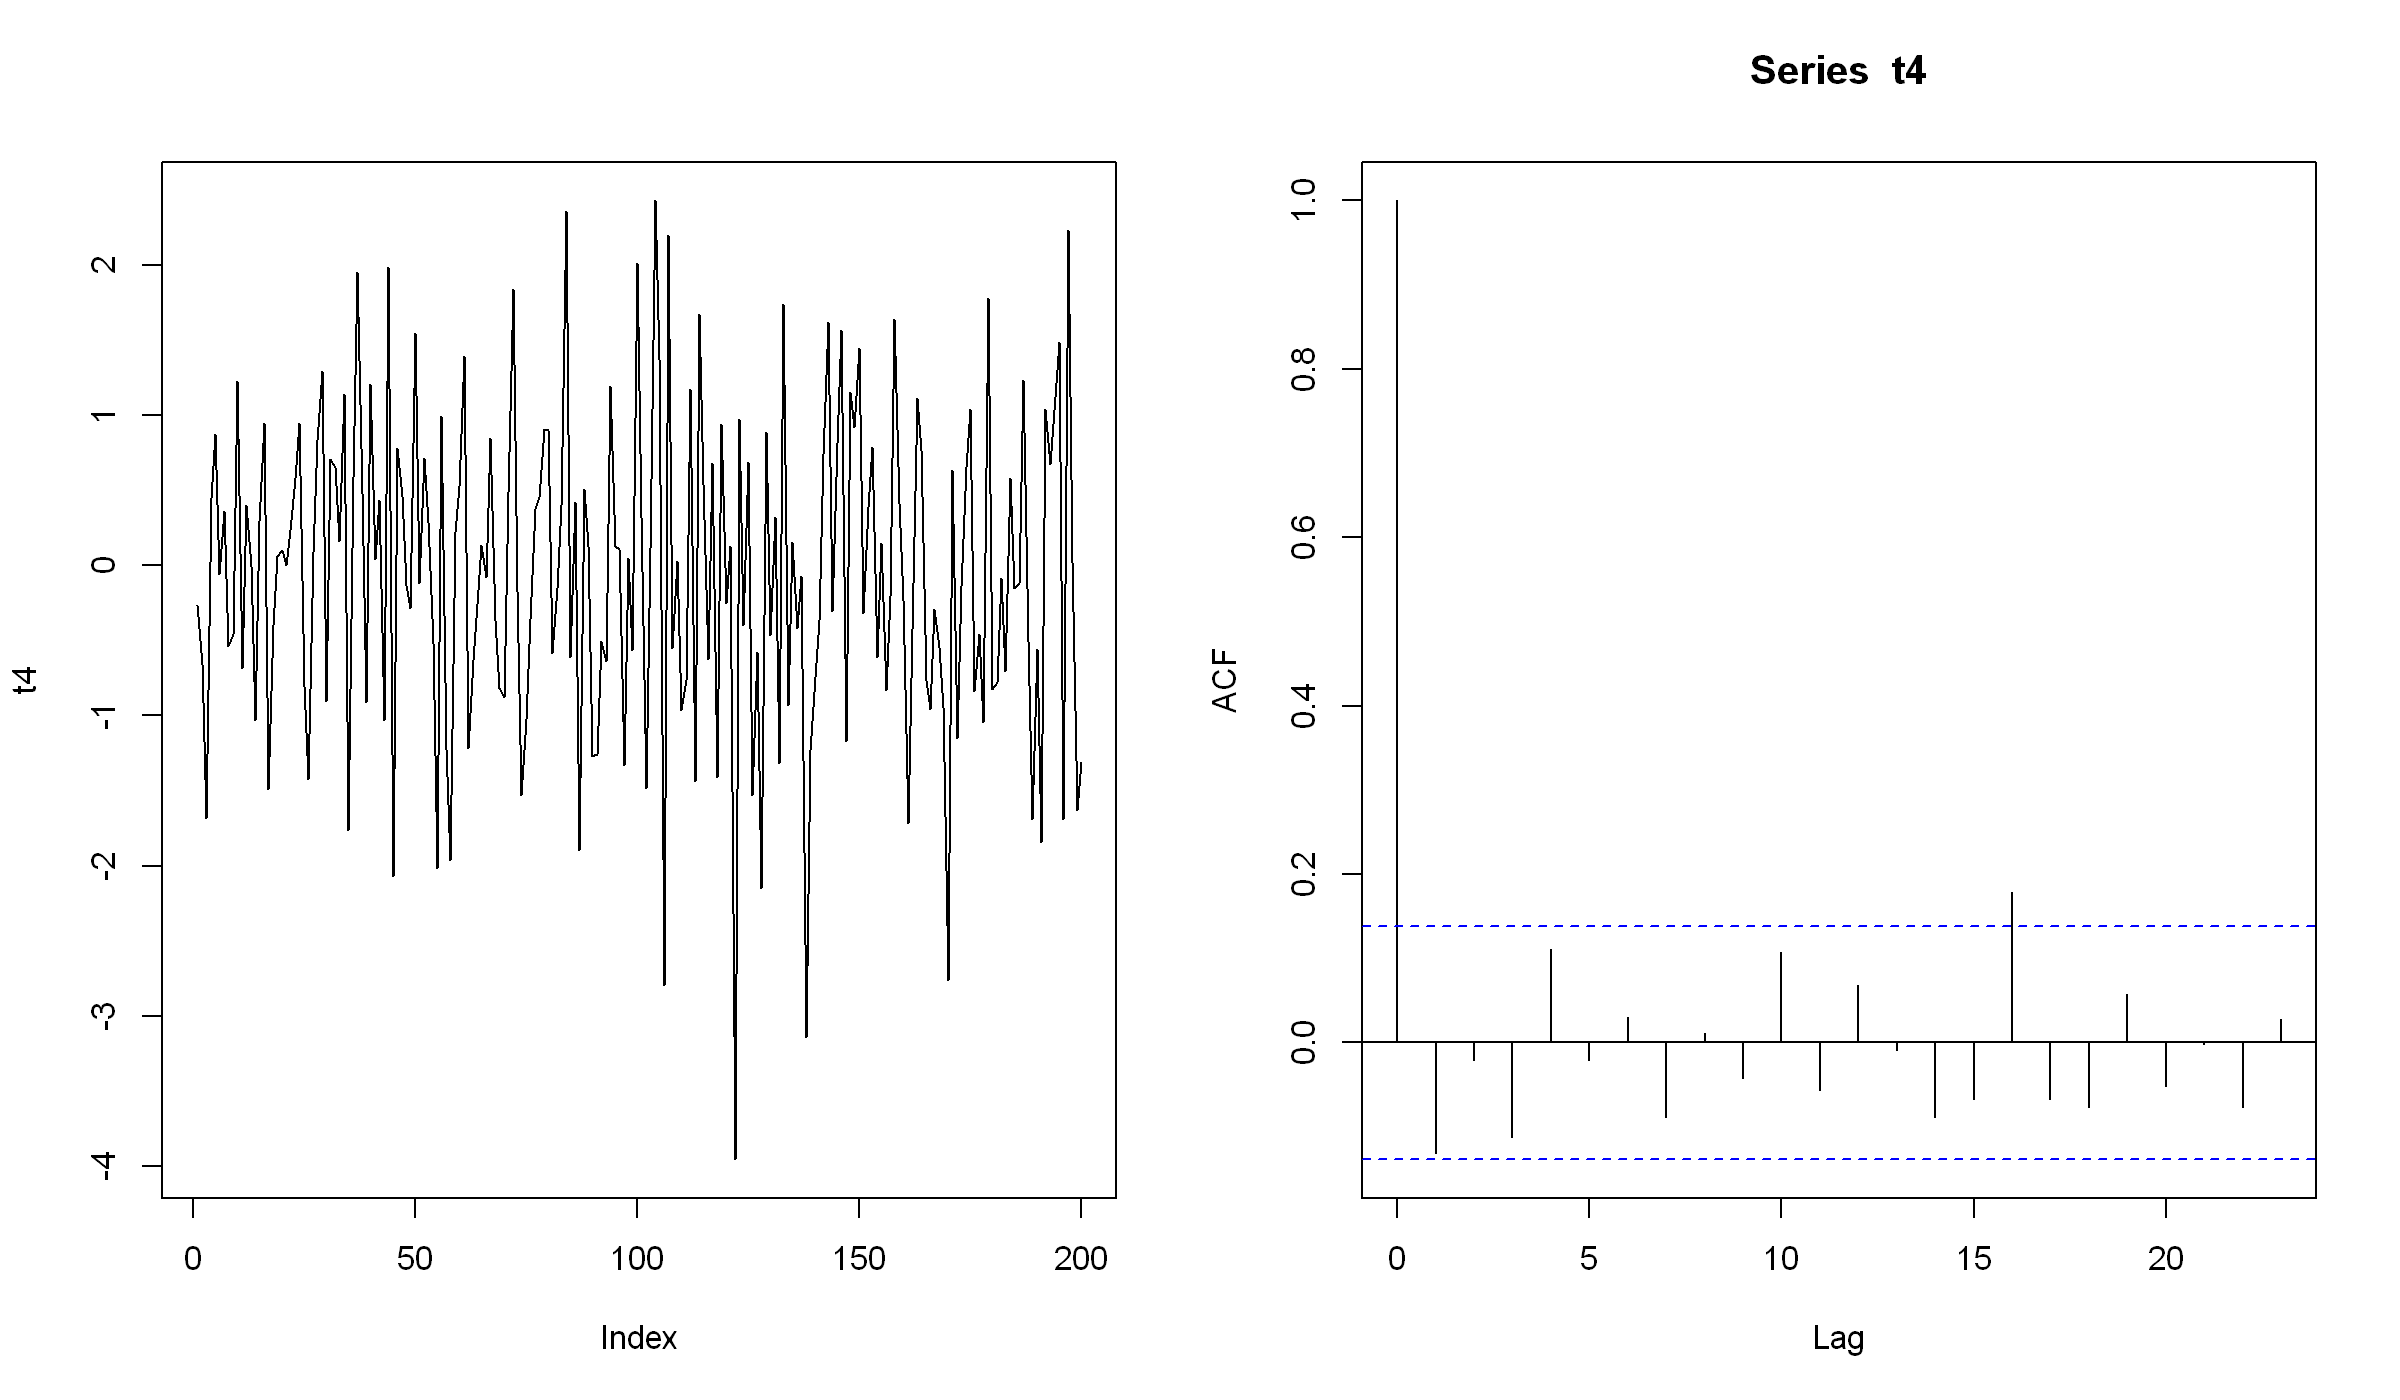

In [532]:
t4 <- rnorm(200)
par(mfrow=c(1,2))
plot(t4,type="l")
acf(t4)

In [586]:
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 200)

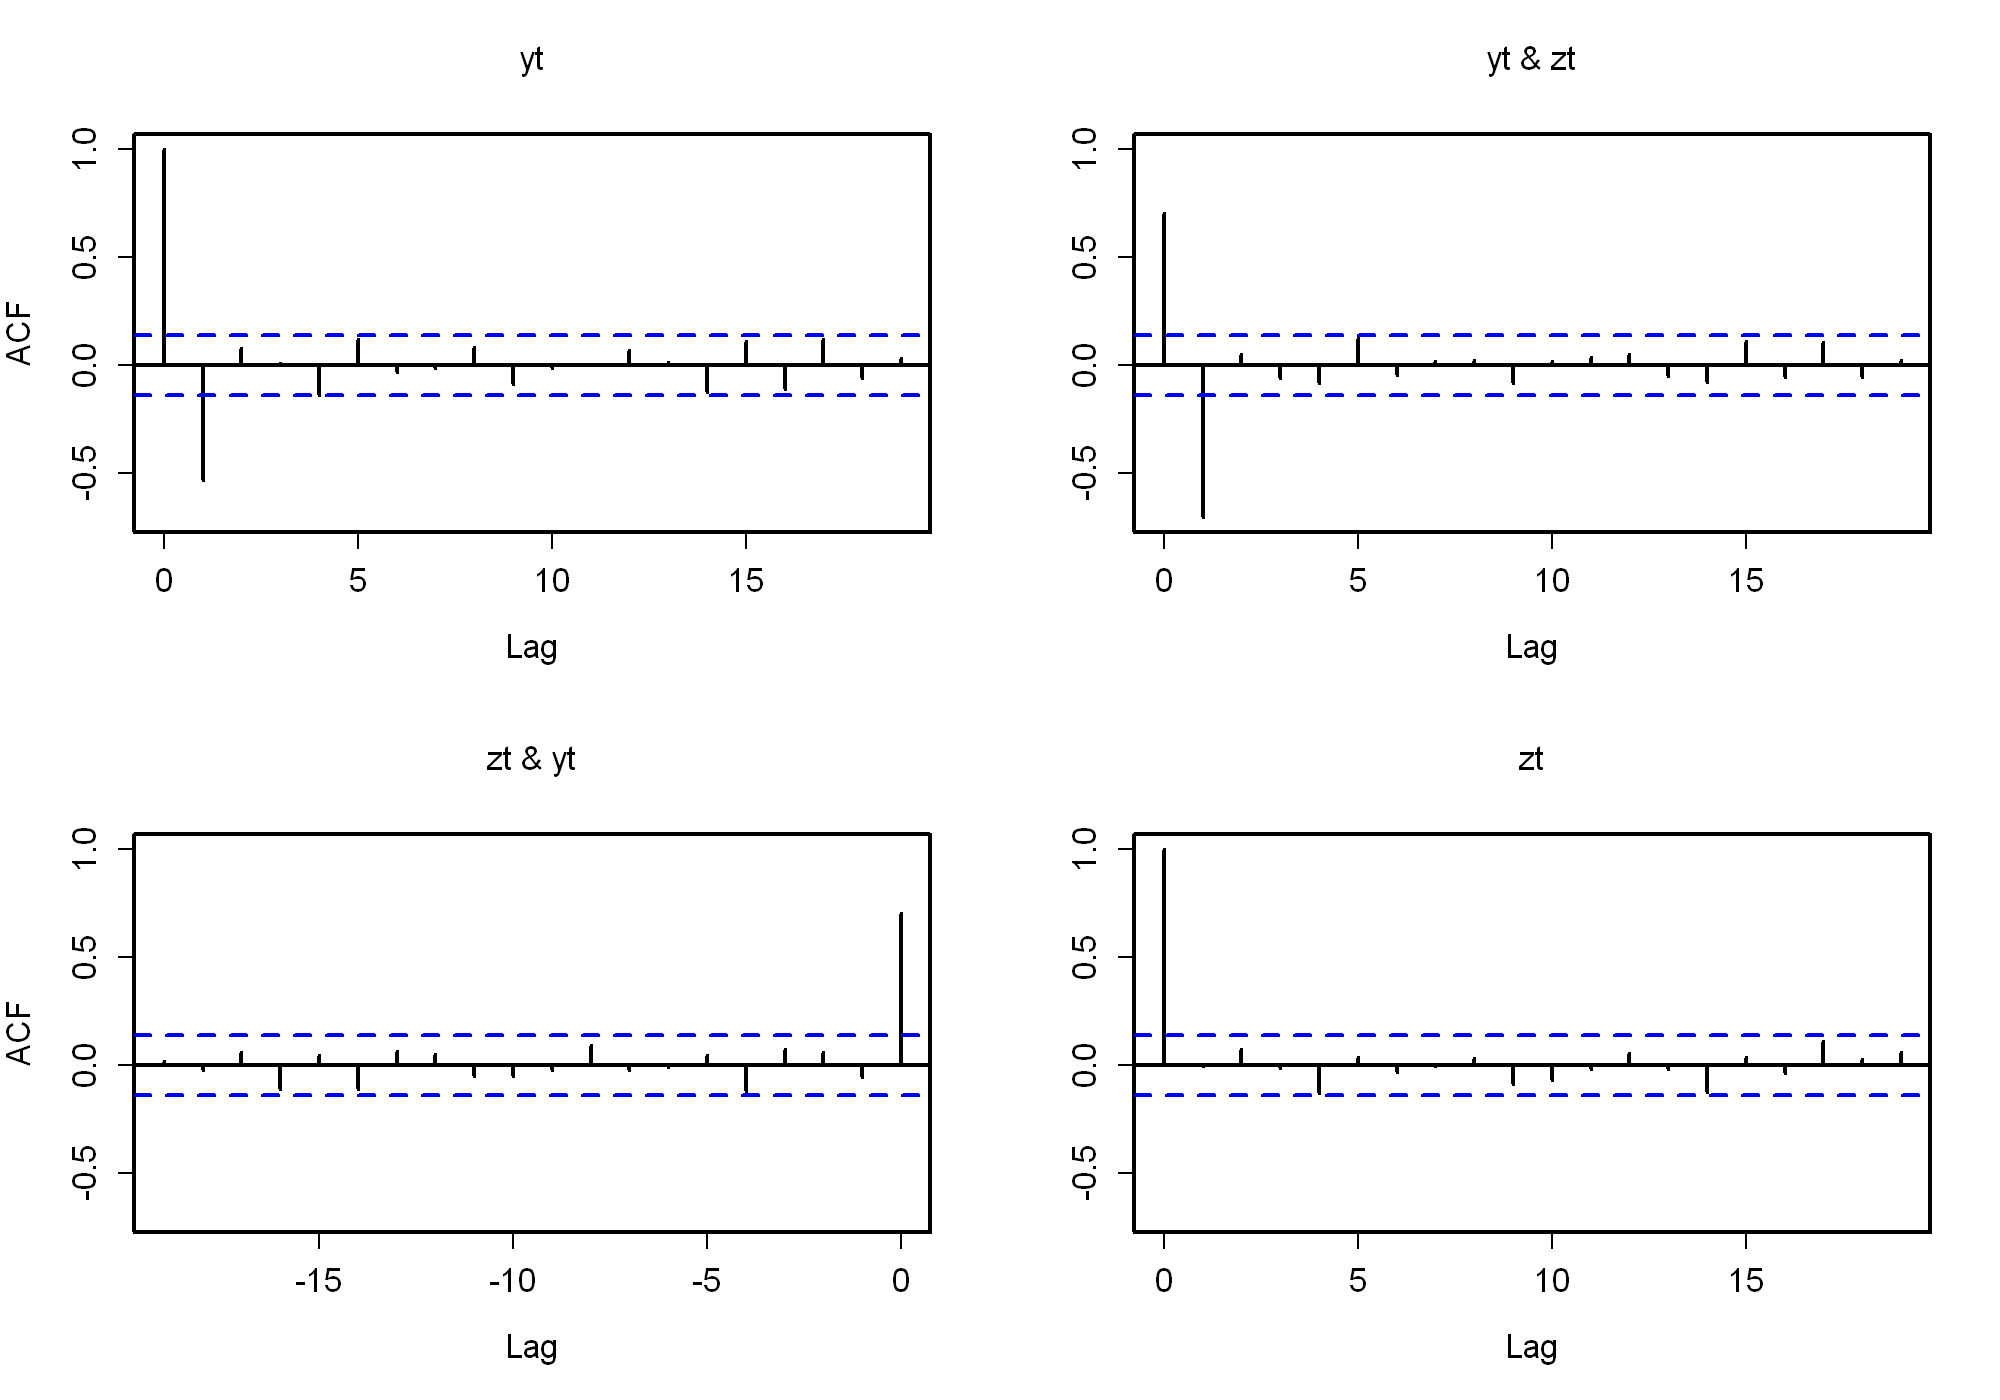

In [587]:
z <- ts(rnorm(200))
xt <- seq(200)+z
yt <- diff(xt)
zt <- xt-seq(200)

par(mfrow=c(2,2),lwd = 2,font.axis = 1.2, font.lab = 1.2, font.main = 1.2,
    cex.axis = 1.2, cex.lab = 1.2, cex.main = 1.2)
acf(ts.union(yt,zt),na.action = na.omit)

In [590]:
print(abs(polyroot(c(1,0,-1))))

[1] 1 1


In [615]:
print(abs(polyroot(c(1,0,-1))))

[1] 1 1
